# Model Training – Baseline Logistic Regression

## Objective

The objective of this notebook is to develop a baseline predictive model for customer credit delinquency using Logistic Regression.

This notebook follows the complete machine learning workflow:

- Load engineered dataset
- Prepare features and target
- Split into training and testing sets
- Scale numerical features
- Train Logistic Regression model
- Evaluate model performance
- Interpret important features
- Save the trained model for future use

The baseline model serves as the benchmark against which more complex models will be compared in later stages.

In [15]:
from src.config import *
from src.data_cleaning import *
from src.preprocessing import *
from src.feature_engineering import *
from src.modeling import *

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [17]:
df = load_dataset(
    PROCESSED_DATA_DIR / "engineered_data.csv"
)

df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Income_Group,Credit_Score_Band,Utilization_Level,Debt_Burden,Age_Group,Loan_to_Income_Ratio,Missed_Payment_Rate,Financial_Stress_Index,Risk_Score,Risk_Category
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,...,High,Poor,Moderate,Moderate,Middle Age,0.098502,0.500000,0.507429,1.0,Low
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,...,Upper Middle,Poor,Moderate,Low,Senior,0.172289,1.000000,0.539407,2.0,Medium
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,...,High,Poor,Moderate,Moderate,Middle Age,0.073035,0.000000,0.324487,0.0,Low
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,...,Upper Middle,Poor,Moderate,Moderate,Adult,0.873180,0.500000,0.482685,1.0,Low
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,...,Low,Poor,Low,Severe,Middle Age,0.345655,0.333333,0.434658,2.0,Medium


In [18]:
print(df.shape)

df.info()

(500, 29)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             500 non-null    str    
 1   Age                     500 non-null    int64  
 2   Income                  500 non-null    float64
 3   Credit_Score            500 non-null    float64
 4   Credit_Utilization      500 non-null    float64
 5   Missed_Payments         500 non-null    int64  
 6   Delinquent_Account      500 non-null    int64  
 7   Loan_Balance            500 non-null    float64
 8   Debt_to_Income_Ratio    500 non-null    float64
 9   Employment_Status       500 non-null    str    
 10  Account_Tenure          500 non-null    int64  
 11  Credit_Card_Type        500 non-null    str    
 12  Location                500 non-null    str    
 13  Month_1                 500 non-null    str    
 14  Month_2                 500 non-null    str

In [19]:
df = df.drop(columns=["Customer_ID"])

In [20]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

print("Categorical features encoded successfully.")

Categorical features encoded successfully.


In [21]:
X, y = split_features_target(
    df,
    "Delinquent_Account"
)

print(X.shape)
print(y.shape)

(500, 27)
(500,)


In [22]:
X_train, X_test, y_train, y_test = split_train_test(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
print(X_train.shape)
print(X_test.shape)

(400, 27)
(100, 27)


In [24]:
numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

In [25]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [26]:
baseline_model = build_logistic_regression()

In [27]:
baseline_model = train_model(
    baseline_model,
    X_train_scaled,
    y_train
)

In [28]:
metrics = evaluate_model(
    baseline_model,
    X_test_scaled,
    y_test
)

metrics

,Metric,Value
0,Accuracy,0.840000
1,Precision,0.000000
2,Recall,0.000000
3,F1 Score,0.000000
4,ROC AUC,0.451637


In [29]:
generate_classification_report(
    baseline_model,
    X_test_scaled,
    y_test
)

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100



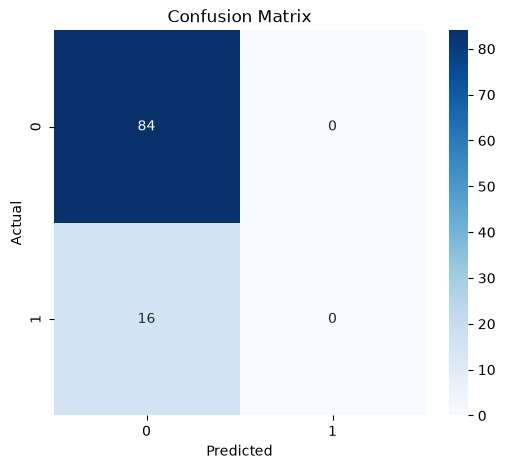

In [30]:
plot_confusion_matrix(
    baseline_model,
    X_test_scaled,
    y_test
)

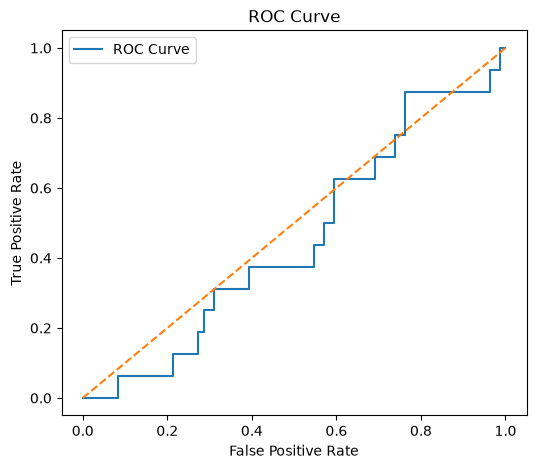

In [31]:
plot_roc_curve(
    baseline_model,
    X_test_scaled,
    y_test
)

In [32]:
metrics.to_csv(
    REPORTS_DIR / "logistic_regression_metrics.csv",
    index=False
)

print("Metrics saved successfully.")

Metrics saved successfully.


In [33]:
importance = logistic_feature_importance(
    baseline_model,
    X_train.columns
)

importance.head(10)

,Feature,Coefficient,Absolute
25,Risk_Score,0.367140,0.367140
14,Month_4,-0.304360,0.304360
3,Credit_Utilization,0.283616,0.283616
22,Loan_to_Income_Ratio,-0.272121,0.272121
19,Utilization_Level,0.250197,0.250197
11,Month_1,0.249181,0.249181
2,Credit_Score,0.199290,0.199290
9,Credit_Card_Type,-0.161735,0.161735
8,Account_Tenure,-0.145472,0.145472
4,Missed_Payments,-0.133206,0.133206


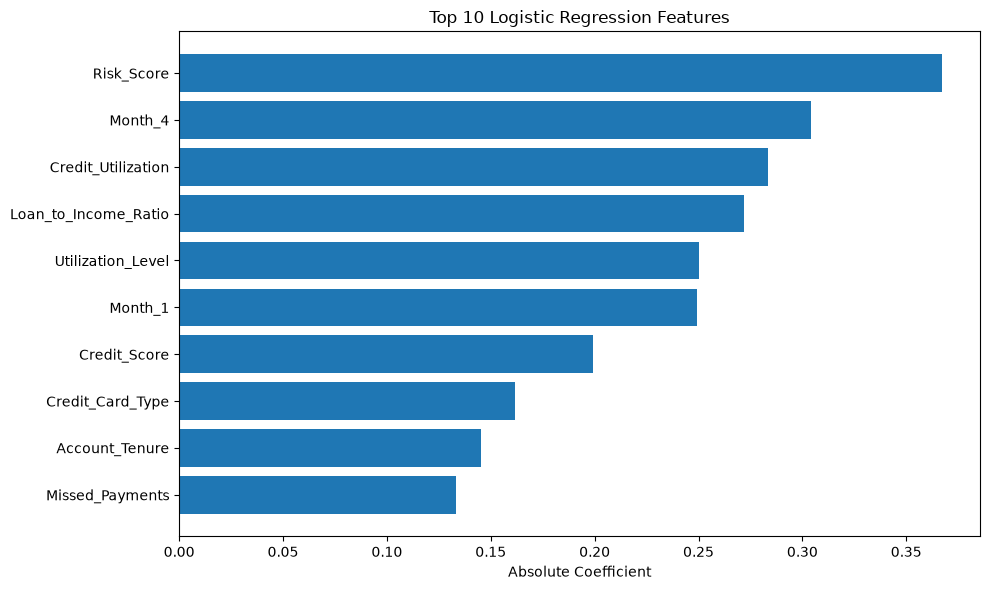

In [34]:
import matplotlib.pyplot as plt

top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute"]
)

plt.xlabel("Absolute Coefficient")

plt.title("Top 10 Logistic Regression Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [35]:
plt.savefig(
    VISUALS_DIR / "logistic_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [36]:
save_model(
    baseline_model,
    MODELS_DIR / "logistic_regression.pkl"
)

Model saved to D:\Geldium-Credit-Delinquency-Risk-Analysis\models\logistic_regression.pkl


# Baseline Model Summary

## Model
- Logistic Regression

## Objective
Predict customer credit delinquency.

## Dataset
- Engineered dataset
- Cleaned and feature engineered

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Key Observations
- Logistic Regression provides an interpretable baseline model.
- Feature coefficients identify important financial risk indicators.
- Results will be compared against Decision Tree and Random Forest models in the next phase.

In [37]:
predictions = X_test.copy()

predictions["Actual"] = y_test.values

predictions["Predicted"] = baseline_model.predict(X_test_scaled)

predictions["Probability"] = predict_probability(
    baseline_model,
    X_test_scaled
)

predictions.head(10)

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,...,Debt_Burden,Age_Group,Loan_to_Income_Ratio,Missed_Payment_Rate,Financial_Stress_Index,Risk_Score,Risk_Category,Actual,Predicted,Probability
57,43,107193.0,843.0,0.362736,0,70793.0,0.357470,0,12,4,...,0,0,0.660426,0.000000,0.183233,0.0,1,0,0,0.279316
413,52,109074.0,401.0,0.397534,0,61210.0,0.376581,5,6,1,...,0,1,0.561179,0.000000,0.397620,1.0,1,0,0,0.154283
487,42,188420.0,550.0,0.384149,1,86846.0,0.420648,3,18,2,...,0,0,0.460917,0.166667,0.379230,1.0,1,0,0,0.291574
416,41,126888.0,793.0,0.337757,6,63412.0,0.337000,3,1,4,...,2,0,0.499748,1.000000,0.444599,1.0,1,0,0,0.150035
25,19,193998.0,515.0,0.255552,5,45776.0,0.259893,0,12,1,...,2,3,0.235961,0.833333,0.489467,1.0,1,0,0,0.100655
320,18,53513.0,391.0,0.835958,2,82382.0,0.343389,3,0,3,...,2,3,1.539476,0.333333,0.586806,2.0,2,0,0,0.084290
327,26,106267.0,471.0,0.479433,2,43927.0,0.301613,0,13,0,...,2,3,0.413364,0.333333,0.450868,1.0,1,0,0,0.252119
101,70,155734.0,563.0,0.560339,3,79354.0,0.253143,2,6,1,...,2,2,0.509548,0.500000,0.458825,0.0,1,0,0,0.109779
62,64,155507.0,801.0,0.363593,0,81202.0,0.488734,5,19,4,...,0,2,0.522176,0.000000,0.235354,1.0,1,0,0,0.201374
92,31,90353.0,372.0,0.396749,6,59192.0,0.184346,5,3,3,...,1,0,0.655119,1.000000,0.612547,2.0,2,0,0,0.062899
